In [33]:
import pandas as pd

In [34]:
from sklearn.datasets import fetch_california_housing

In [35]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
df = fetch_california_housing()

In [37]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [38]:
dataset = pd.DataFrame(df.data ,columns=df.feature_names)

In [39]:
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [40]:
x = dataset
y = df.target

In [41]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [42]:
y.size

20640

In [43]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.30, random_state=43)

In [44]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [45]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [47]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [48]:
mse = cross_val_score(lr,x_train,y_train,scoring='neg_mean_squared_error',cv=5)

In [49]:
np.mean(mse)

np.float64(-0.6659087212206736)

In [50]:
lr_pred = lr.predict(x_test)

In [51]:
lr_pred

array([1.77749703, 1.93671479, 1.52373875, ..., 0.45709074, 1.90857683,
       1.87343893])

In [52]:
from sklearn.metrics import r2_score

In [53]:
score=r2_score(lr_pred,y_test)

In [54]:
score

0.3982613182707684

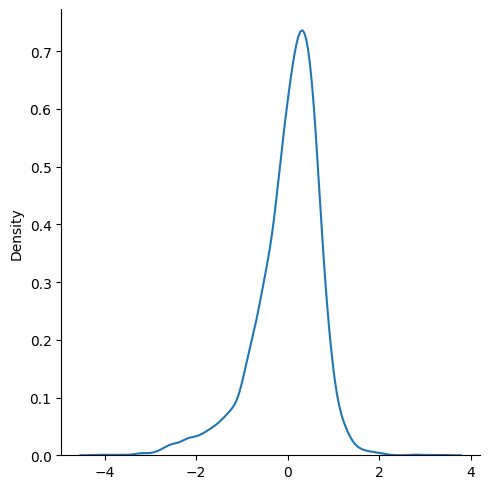

In [55]:
import seaborn as sns
sns.displot(lr_pred-y_test,kind='kde')